# Market Risk Analytics Platform

## Notebook 01 — Data Collection, Validation and Market Analysis

### Objectives

This notebook builds the market-data foundation of the Market Risk Analytics pipeline.

It performs:

- collection of historical market prices;
- data-quality controls;
- cleaning and calendar alignment;
- calculation of financial returns;
- exploratory analysis of market risk factors;
- generation of reusable datasets for downstream notebooks.

### Pipeline dependencies

This is the first notebook of the project and does not depend on any previous notebook.

It generates the cleaned datasets required by:

- Notebook 02 — Portfolio and P&L Analysis;
- Notebook 03 — VaR and Expected Shortfall;
- Notebook 04 — Backtesting and Stress Testing;
- Notebook 05 — Risk Factors and Reporting.

## Monter Google Drive

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


## Définir l’arborescence du proje

In [ ]:
from pathlib import Path
import sys

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/market-risk-analytics"
)

NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
SRC_DIR = PROJECT_ROOT / "src"
CONFIG_DIR = PROJECT_ROOT / "config"

DATA_DIR = PROJECT_ROOT / "data"
DATA_RAW_DIR = DATA_DIR / "raw"
DATA_PROCESSED_DIR = DATA_DIR / "processed"

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = PROJECT_ROOT / "figures"

PROJECT_DIRECTORIES = [
    NOTEBOOKS_DIR,
    SRC_DIR,
    CONFIG_DIR,
    DATA_RAW_DIR,
    DATA_PROCESSED_DIR,
    REPORTS_DIR,
    FIGURES_DIR,
]

for directory in PROJECT_DIRECTORIES:
    directory.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")
print("\nProject directories created successfully.")

Project root: /content/drive/MyDrive/market-risk-analytics

Project directories created successfully.


In [ ]:
for directory in PROJECT_DIRECTORIES:
    print(
        f"{'OK' if directory.exists() else 'MISSING'}"
        f" | {directory}"
    )

OK | /content/drive/MyDrive/market-risk-analytics/notebooks
OK | /content/drive/MyDrive/market-risk-analytics/src
OK | /content/drive/MyDrive/market-risk-analytics/config
OK | /content/drive/MyDrive/market-risk-analytics/data/raw
OK | /content/drive/MyDrive/market-risk-analytics/data/processed
OK | /content/drive/MyDrive/market-risk-analytics/reports
OK | /content/drive/MyDrive/market-risk-analytics/figures


## Installer les bibliothèques

In [ ]:
!pip install -q yfinance pyarrow openpyxl

## Importer les bibliothèques

In [ ]:
from datetime import datetime, timezone
import hashlib
import json
import platform
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print(f"Python version: {platform.python_version()}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Python version: 3.12.13
Pandas version: 2.2.2
NumPy version: 2.0.2


## Paramètres du projet

In [ ]:
PIPELINE_VERSION = "1.0.0"

START_DATE = "2018-01-01"
END_DATE = None

TRADING_DAYS_PER_YEAR = 252

ASSETS = {
    "US_EQUITY": {
        "ticker": "SPY",
        "description": "US equities — S&P 500 ETF",
        "risk_factor": "Equity",
        "currency": "USD",
    },
    "EUROPE_EQUITY": {
        "ticker": "FEZ",
        "description": "European equities — Euro Stoxx 50 ETF",
        "risk_factor": "Equity",
        "currency": "USD",
    },
    "US_TREASURY": {
        "ticker": "IEF",
        "description": "US government bonds — 7-10 year Treasury ETF",
        "risk_factor": "Interest Rate",
        "currency": "USD",
    },
    "CORPORATE_BOND": {
        "ticker": "LQD",
        "description": "Investment-grade corporate bond ETF",
        "risk_factor": "Credit and Interest Rate",
        "currency": "USD",
    },
    "GOLD": {
        "ticker": "GLD",
        "description": "Gold ETF",
        "risk_factor": "Commodity",
        "currency": "USD",
    },
    "EURUSD": {
        "ticker": "EURUSD=X",
        "description": "EUR/USD exchange rate",
        "risk_factor": "Foreign Exchange",
        "currency": "USD per EUR",
    },
}

ASSET_NAMES = list(ASSETS.keys())
TICKERS = [asset["ticker"] for asset in ASSETS.values()]

ticker_to_asset = {
    properties["ticker"]: asset_name
    for asset_name, properties in ASSETS.items()
}

asset_reference = pd.DataFrame.from_dict(
    ASSETS,
    orient="index",
)

asset_reference.index.name = "asset"

asset_reference

,ticker,description,risk_factor,currency
asset,,,,
US_EQUITY,SPY,US equities — S&P 500 ETF,Equity,USD
EUROPE_EQUITY,FEZ,European equities — Euro Stoxx 50 ETF,Equity,USD
US_TREASURY,IEF,US government bonds — 7-10 year Treasury ETF,Interest Rate,USD
CORPORATE_BOND,LQD,Investment-grade corporate bond ETF,Credit and Interest Rate,USD
GOLD,GLD,Gold ETF,Commodity,USD
EURUSD,EURUSD=X,EUR/USD exchange rate,Foreign Exchange,USD per EUR


## Vérifier la configuration

In [ ]:
def validate_project_configuration(
    assets: dict,
    start_date: str,
) -> None:
    """Validate the main market-data configuration."""

    if not assets:
        raise ValueError("The asset universe cannot be empty.")

    required_fields = {
        "ticker",
        "description",
        "risk_factor",
        "currency",
    }

    tickers = []

    for asset_name, properties in assets.items():
        missing_fields = required_fields - set(properties)

        if missing_fields:
            raise ValueError(
                f"{asset_name} is missing fields: "
                f"{sorted(missing_fields)}"
            )

        tickers.append(properties["ticker"])

    if len(tickers) != len(set(tickers)):
        raise ValueError("Duplicate tickers detected.")

    parsed_start_date = pd.Timestamp(start_date)

    if parsed_start_date >= pd.Timestamp.today():
        raise ValueError("START_DATE must be in the past.")

    print("Configuration validation successful.")


validate_project_configuration(
    assets=ASSETS,
    start_date=START_DATE,
)

Configuration validation successful.


## Fonction de téléchargement

In [ ]:
def download_market_prices(
    tickers: list[str],
    start_date: str,
    end_date: str | None = None,
) -> pd.DataFrame:
    """
    Download adjusted historical closing prices.

    Parameters
    ----------
    tickers:
        List of financial instrument tickers.
    start_date:
        Start date formatted as YYYY-MM-DD.
    end_date:
        Optional end date formatted as YYYY-MM-DD.

    Returns
    -------
    pd.DataFrame
        DataFrame containing adjusted closing prices.
    """

    if not tickers:
        raise ValueError("At least one ticker must be provided.")

    downloaded_data = yf.download(
        tickers=tickers,
        start=start_date,
        end=end_date,
        auto_adjust=True,
        progress=False,
        group_by="column",
        threads=True,
    )

    if downloaded_data.empty:
        raise RuntimeError(
            "No market data were downloaded. "
            "Check the tickers or the internet connection."
        )

    if isinstance(downloaded_data.columns, pd.MultiIndex):
        if "Close" not in downloaded_data.columns.get_level_values(0):
            raise KeyError(
                "The downloaded dataset does not contain Close prices."
            )

        prices = downloaded_data["Close"].copy()

    else:
        if "Close" not in downloaded_data.columns:
            raise KeyError(
                "The downloaded dataset does not contain Close prices."
            )

        prices = downloaded_data[["Close"]].copy()
        prices.columns = tickers

    if isinstance(prices, pd.Series):
        prices = prices.to_frame()

    prices.index = pd.to_datetime(prices.index)
    prices.index.name = "date"
    prices = prices.sort_index()

    return prices

## Télécharger les données

In [ ]:
raw_prices = download_market_prices(
    tickers=TICKERS,
    start_date=START_DATE,
    end_date=END_DATE,
)

raw_prices = raw_prices.rename(
    columns=ticker_to_asset
)

raw_prices = raw_prices.reindex(
    columns=ASSET_NAMES
)

print(f"Number of observations: {len(raw_prices):,}")
print(f"First date: {raw_prices.index.min().date()}")
print(f"Last date: {raw_prices.index.max().date()}")

raw_prices.head()

Number of observations: 2,234
First date: 2018-01-01
Last date: 2026-07-29


Ticker,US_EQUITY,EUROPE_EQUITY,US_TREASURY,CORPORATE_BOND,GOLD,EURUSD
date,,,,,,
2018-01-01,NaN,NaN,NaN,NaN,NaN,1.200495
2018-01-02,235.954285,31.983484,85.827789,89.042908,125.150002,1.201158
2018-01-03,237.446762,32.108631,85.917542,89.205132,124.820000,1.206345
2018-01-04,238.447540,32.679623,85.876732,89.175629,125.459999,1.201043
2018-01-05,240.036545,33.008141,85.770699,89.146141,125.330002,1.206884


In [ ]:
raw_prices.tail()

Ticker,US_EQUITY,EUROPE_EQUITY,US_TREASURY,CORPORATE_BOND,GOLD,EURUSD
date,,,,,,
2026-07-23,738.179993,67.190002,92.849998,106.260002,371.519989,1.141175
2026-07-24,738.929993,67.690002,93.029999,106.230003,371.899994,1.137682
2026-07-27,739.090027,68.169998,93.279999,106.510002,374.630005,1.139497
2026-07-28,740.859985,68.190002,93.559998,106.830002,369.369995,1.136945
2026-07-29,NaN,NaN,NaN,NaN,NaN,1.140381


## Enregistrer les données brutes

In [ ]:
RAW_PRICES_CSV = DATA_RAW_DIR / "market_prices_raw.csv"
RAW_PRICES_PARQUET = DATA_RAW_DIR / "market_prices_raw.parquet"

raw_prices.to_csv(
    RAW_PRICES_CSV,
    index=True,
)

raw_prices.to_parquet(
    RAW_PRICES_PARQUET,
    index=True,
)

print(f"Saved: {RAW_PRICES_CSV}")
print(f"Saved: {RAW_PRICES_PARQUET}")

Saved: /content/drive/MyDrive/market-risk-analytics/data/raw/market_prices_raw.csv
Saved: /content/drive/MyDrive/market-risk-analytics/data/raw/market_prices_raw.parquet


## Rapport initial de qualité

In [ ]:
def build_data_quality_report(
    prices: pd.DataFrame,
) -> pd.DataFrame:
    """Create a data-quality report for market prices."""

    if prices.empty:
        raise ValueError("The price dataset is empty.")

    report = pd.DataFrame(index=prices.columns)

    report.index.name = "asset"

    report["observation_count"] = prices.count()
    report["missing_count"] = prices.isna().sum()
    report["missing_rate"] = prices.isna().mean()

    report["first_valid_date"] = [
        prices[column].first_valid_index()
        for column in prices.columns
    ]

    report["last_valid_date"] = [
        prices[column].last_valid_index()
        for column in prices.columns
    ]

    report["minimum_price"] = prices.min()
    report["maximum_price"] = prices.max()

    report["zero_or_negative_count"] = (
        prices.le(0).sum()
    )

    report["duplicate_date_count"] = (
        prices.index.duplicated().sum()
    )

    return report


initial_quality_report = build_data_quality_report(
    raw_prices
)

initial_quality_report

,observation_count,missing_count,missing_rate,first_valid_date,last_valid_date,minimum_price,maximum_price,zero_or_negative_count,duplicate_date_count
asset,,,,,,,,,
US_EQUITY,2153,81,0.036258,2018-01-02,2026-07-28,204.418213,757.618225,0,0
EUROPE_EQUITY,2153,81,0.036258,2018-01-02,2026-07-28,20.856178,69.529999,0,0
US_TREASURY,2153,81,0.036258,2018-01-02,2026-07-28,80.396271,105.679947,0,0
CORPORATE_BOND,2153,81,0.036258,2018-01-02,2026-07-28,83.536102,112.422020,0,0
GOLD,2153,81,0.036258,2018-01-02,2026-07-28,111.099998,495.899994,0,0
EURUSD,2232,2,0.000895,2018-01-01,2026-07-29,0.959619,1.251001,0,0


## Vérifications critiques

In [ ]:
def run_critical_price_checks(
    prices: pd.DataFrame,
) -> None:
    """Run critical controls before cleaning market prices."""

    if prices.empty:
        raise ValueError("The downloaded price dataset is empty.")

    if not isinstance(prices.index, pd.DatetimeIndex):
        raise TypeError("The price index must be a DatetimeIndex.")

    if prices.index.duplicated().any():
        duplicated_dates = prices.index[
            prices.index.duplicated()
        ]

        raise ValueError(
            f"Duplicate dates detected: "
            f"{duplicated_dates[:5].tolist()}"
        )

    all_missing_assets = prices.columns[
        prices.isna().all()
    ].tolist()

    if all_missing_assets:
        raise ValueError(
            f"Assets containing only missing values: "
            f"{all_missing_assets}"
        )

    negative_or_zero_assets = prices.columns[
        prices.le(0).any()
    ].tolist()

    if negative_or_zero_assets:
        raise ValueError(
            "Non-positive prices detected for: "
            f"{negative_or_zero_assets}"
        )

    print("Critical price checks passed.")


run_critical_price_checks(raw_prices)

Critical price checks passed.


## Visualiser les valeurs manquantes

In [ ]:
missing_summary = (
    raw_prices
    .isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
)

missing_summary["missing_rate"] = (
    missing_summary["missing_count"]
    / len(raw_prices)
)

missing_summary

,missing_count,missing_rate
asset,,
US_EQUITY,81,0.036258
EUROPE_EQUITY,81,0.036258
US_TREASURY,81,0.036258
CORPORATE_BOND,81,0.036258
GOLD,81,0.036258
EURUSD,2,0.000895


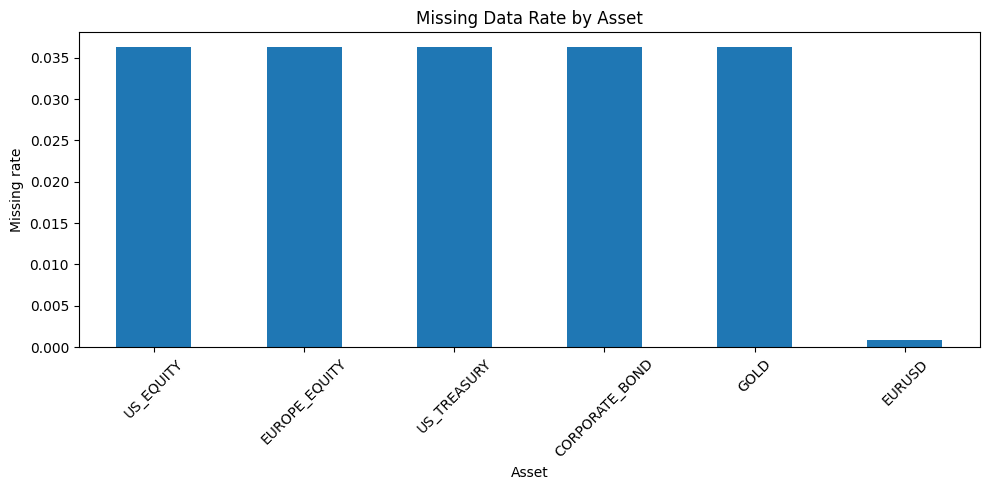

In [ ]:
missing_summary["missing_rate"].plot(
    kind="bar",
    figsize=(10, 5),
    title="Missing Data Rate by Asset",
)

plt.ylabel("Missing rate")
plt.xlabel("Asset")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Cellule 14 — Nettoyage des prix

Pour des actifs provenant de marchés différents, certaines dates de cotation ne correspondent pas parfaitement.

Nous allons :

trier les dates ;

supprimer les dates dupliquées ;

appliquer un remplissage limité ;

supprimer les lignes encore incomplètes.

In [ ]:
def clean_market_prices(
    prices: pd.DataFrame,
    forward_fill_limit: int = 3,
) -> pd.DataFrame:
    """
    Clean and align market-price series.

    A limited forward fill is used to handle small calendar
    differences without propagating stale prices excessively.
    """

    if prices.empty:
        raise ValueError("The price dataset cannot be empty.")

    cleaned_prices = prices.copy()

    cleaned_prices = cleaned_prices.sort_index()

    cleaned_prices = cleaned_prices[
        ~cleaned_prices.index.duplicated(keep="first")
    ]

    cleaned_prices = cleaned_prices.apply(
        pd.to_numeric,
        errors="coerce",
    )

    cleaned_prices = cleaned_prices.replace(
        [np.inf, -np.inf],
        np.nan,
    )

    cleaned_prices = cleaned_prices.ffill(
        limit=forward_fill_limit
    )

    cleaned_prices = cleaned_prices.dropna(
        how="any"
    )

    if cleaned_prices.empty:
        raise ValueError(
            "No observations remain after cleaning."
        )

    if cleaned_prices.le(0).any().any():
        raise ValueError(
            "Cleaned prices contain non-positive values."
        )

    return cleaned_prices


clean_prices = clean_market_prices(
    raw_prices,
    forward_fill_limit=3,
)

print(f"Raw observations: {len(raw_prices):,}")
print(f"Clean observations: {len(clean_prices):,}")
print(
    f"Removed observations: "
    f"{len(raw_prices) - len(clean_prices):,}"
)

clean_prices.head()

Raw observations: 2,234
Clean observations: 2,233
Removed observations: 1


asset,US_EQUITY,EUROPE_EQUITY,US_TREASURY,CORPORATE_BOND,GOLD,EURUSD
date,,,,,,
2018-01-02,235.954285,31.983484,85.827789,89.042908,125.150002,1.201158
2018-01-03,237.446762,32.108631,85.917542,89.205132,124.820000,1.206345
2018-01-04,238.447540,32.679623,85.876732,89.175629,125.459999,1.201043
2018-01-05,240.036545,33.008141,85.770699,89.146141,125.330002,1.206884
2018-01-08,240.475494,32.875175,85.729919,89.138786,125.309998,1.203746


## Comparer avant et après nettoyage

In [ ]:
cleaning_summary = pd.DataFrame({
    "raw_missing_count": raw_prices.isna().sum(),
    "clean_missing_count": clean_prices.isna().sum(),
    "raw_observations": len(raw_prices),
    "clean_observations": len(clean_prices),
})

cleaning_summary

,raw_missing_count,clean_missing_count,raw_observations,clean_observations
asset,,,,
US_EQUITY,81,0,2234,2233
EUROPE_EQUITY,81,0,2234,2233
US_TREASURY,81,0,2234,2233
CORPORATE_BOND,81,0,2234,2233
GOLD,81,0,2234,2233
EURUSD,2,0,2234,2233


In [ ]:
assert not clean_prices.empty
assert not clean_prices.isna().any().any()
assert not clean_prices.index.duplicated().any()
assert clean_prices.gt(0).all().all()
assert list(clean_prices.columns) == ASSET_NAMES

print("Cleaned dataset validation successful.")

Cleaned dataset validation successful.


## Calcul des rendements

Nous conserverons :

les rendements simples pour les calculs de P&L ;

les rendements logarithmiques pour certaines analyses statistiques.

In [ ]:
def calculate_financial_returns(
    prices: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Calculate simple and logarithmic returns."""

    if prices.empty:
        raise ValueError("Price data cannot be empty.")

    if prices.le(0).any().any():
        raise ValueError(
            "Prices must be strictly positive."
        )

    simple_returns = (
        prices
        .pct_change(fill_method=None)
        .replace([np.inf, -np.inf], np.nan)
        .dropna(how="any")
    )

    log_returns = (
        np.log(prices / prices.shift(1))
        .replace([np.inf, -np.inf], np.nan)
        .dropna(how="any")
    )

    common_index = simple_returns.index.intersection(
        log_returns.index
    )

    simple_returns = simple_returns.loc[common_index]
    log_returns = log_returns.loc[common_index]

    simple_returns.index.name = "date"
    log_returns.index.name = "date"

    return simple_returns, log_returns


simple_returns, log_returns = calculate_financial_returns(
    clean_prices
)

print(f"Simple return observations: {len(simple_returns):,}")
print(f"Log return observations: {len(log_returns):,}")

simple_returns.head()

Simple return observations: 2,232
Log return observations: 2,232


asset,US_EQUITY,EUROPE_EQUITY,US_TREASURY,CORPORATE_BOND,GOLD,EURUSD
date,,,,,,
2018-01-03,0.006325,0.003913,0.001046,0.001822,-0.002637,0.004319
2018-01-04,0.004215,0.017783,-0.000475,-0.000331,0.005127,-0.004396
2018-01-05,0.006664,0.010053,-0.001235,-0.000331,-0.001036,0.004864
2018-01-08,0.001829,-0.004028,-0.000475,-0.000083,-0.000160,-0.002600
2018-01-09,0.002264,0.000714,-0.004757,-0.003640,-0.004628,-0.005566


## Contrôle des rendements

In [ ]:
def validate_returns(
    returns: pd.DataFrame,
    dataset_name: str,
) -> None:
    """Validate a financial-return dataset."""

    if returns.empty:
        raise ValueError(
            f"{dataset_name} is empty."
        )

    if returns.isna().any().any():
        raise ValueError(
            f"{dataset_name} contains missing values."
        )

    if not np.isfinite(
        returns.to_numpy()
    ).all():
        raise ValueError(
            f"{dataset_name} contains infinite values."
        )

    extreme_return_count = int(
        returns.abs().gt(0.50).sum().sum()
    )

    print(
        f"{dataset_name}: "
        f"{len(returns):,} observations"
    )

    print(
        f"Returns above 50% in absolute value: "
        f"{extreme_return_count}"
    )


validate_returns(
    simple_returns,
    "Simple returns",
)

validate_returns(
    log_returns,
    "Log returns",
)

Simple returns: 2,232 observations
Returns above 50% in absolute value: 0
Log returns: 2,232 observations
Returns above 50% in absolute value: 0


## Détecter les rendements extrêmes

In [ ]:
EXTREME_RETURN_THRESHOLD = 0.15

extreme_return_records = []

for asset in simple_returns.columns:
    extreme_mask = (
        simple_returns[asset].abs()
        >= EXTREME_RETURN_THRESHOLD
    )

    asset_extremes = simple_returns.loc[
        extreme_mask,
        [asset],
    ].copy()

    for date, row in asset_extremes.iterrows():
        extreme_return_records.append({
            "date": date,
            "asset": asset,
            "simple_return": row[asset],
            "absolute_return": abs(row[asset]),
        })

extreme_returns = pd.DataFrame(
    extreme_return_records
)

if not extreme_returns.empty:
    extreme_returns = extreme_returns.sort_values(
        "absolute_return",
        ascending=False,
    )

extreme_returns.head(20)

""


## Prix normalisés

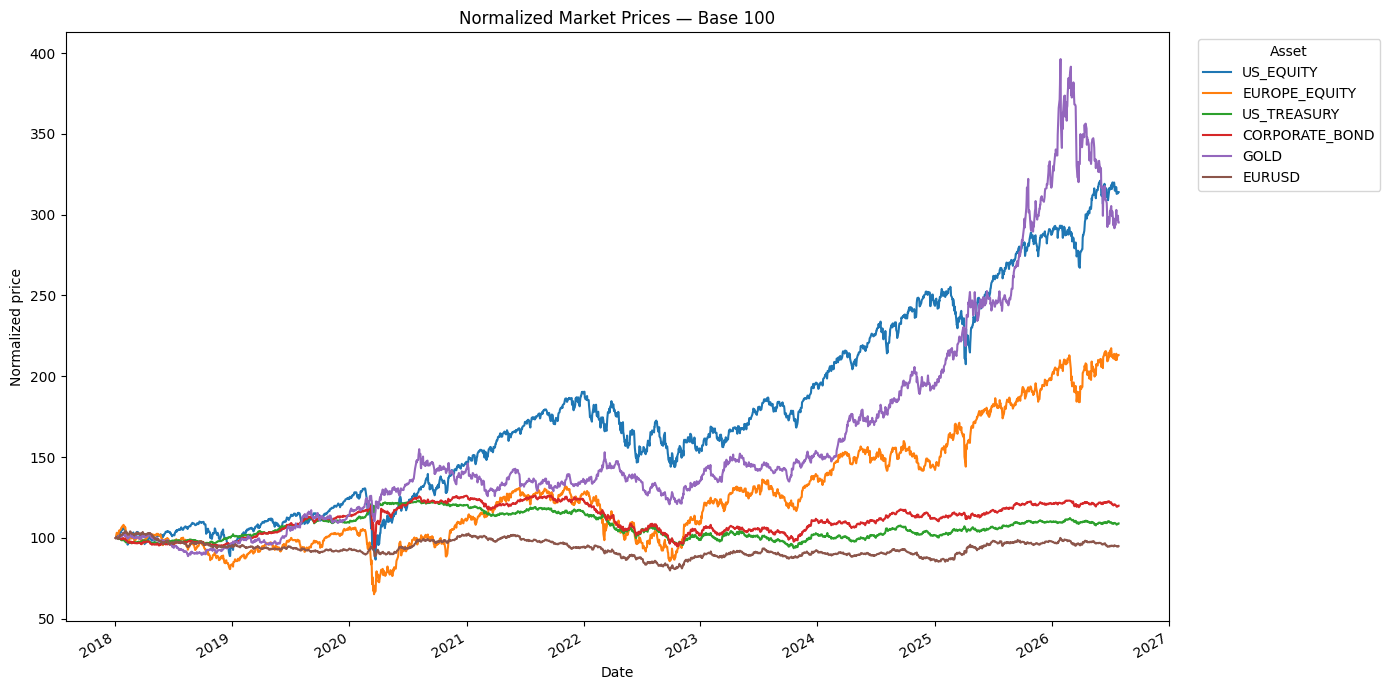

In [ ]:
normalized_prices = (
    clean_prices
    / clean_prices.iloc[0]
    * 100
)

normalized_prices.plot(
    figsize=(14, 7),
    title="Normalized Market Prices — Base 100",
)

plt.xlabel("Date")
plt.ylabel("Normalized price")
plt.legend(
    title="Asset",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)
plt.tight_layout()
plt.show()

### Interpretation

The normalized-price chart compares the cumulative evolution of assets with different price levels.

A base value of 100 is assigned to each asset at the beginning of the sample. This representation facilitates the comparison of performance, market cycles and drawdown periods across asset classes.

## Statistiques descriptives

In [ ]:
def calculate_market_statistics(
    returns: pd.DataFrame,
    trading_days: int = 252,
) -> pd.DataFrame:
    """Calculate descriptive market-risk statistics."""

    statistics = pd.DataFrame(
        index=returns.columns
    )

    statistics.index.name = "asset"

    statistics["daily_mean"] = returns.mean()
    statistics["daily_volatility"] = returns.std()

    statistics["annualized_return"] = (
        returns.mean() * trading_days
    )

    statistics["annualized_volatility"] = (
        returns.std() * np.sqrt(trading_days)
    )

    statistics["minimum_daily_return"] = (
        returns.min()
    )

    statistics["maximum_daily_return"] = (
        returns.max()
    )

    statistics["skewness"] = returns.skew()
    statistics["excess_kurtosis"] = returns.kurtosis()

    statistics["positive_return_rate"] = (
        returns.gt(0).mean()
    )

    return statistics


market_statistics = calculate_market_statistics(
    simple_returns,
    trading_days=TRADING_DAYS_PER_YEAR,
)

market_statistics

,daily_mean,daily_volatility,annualized_return,annualized_volatility,minimum_daily_return,maximum_daily_return,skewness,excess_kurtosis,positive_return_rate
asset,,,,,,,,,
US_EQUITY,0.000583,0.011833,0.146898,0.187836,-0.109424,0.105019,-0.293147,13.787032,0.533154
EUROPE_EQUITY,0.000431,0.013481,0.108510,0.214005,-0.124643,0.094077,-0.541356,10.786152,0.527778
US_TREASURY,0.000048,0.004266,0.012029,0.067714,-0.025072,0.026416,0.199501,3.343766,0.483423
CORPORATE_BOND,0.000098,0.005690,0.024633,0.090323,-0.050030,0.073918,0.551428,27.833743,0.504480
GOLD,0.000540,0.010425,0.135971,0.165490,-0.102742,0.063587,-0.638382,7.522923,0.518817
EURUSD,-0.000013,0.004486,-0.003328,0.071213,-0.027752,0.027919,0.051569,2.360629,0.489695


## Volatilité annualisée

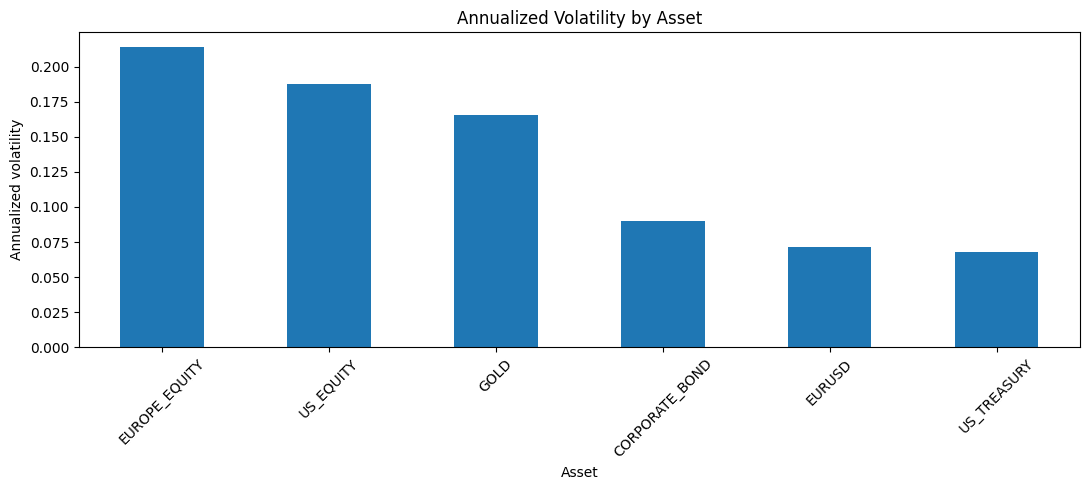

In [ ]:
annualized_volatility = (
    market_statistics["annualized_volatility"]
    .sort_values(ascending=False)
)

annualized_volatility.plot(
    kind="bar",
    figsize=(11, 5),
    title="Annualized Volatility by Asset",
)

plt.ylabel("Annualized volatility")
plt.xlabel("Asset")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Matrice de corrélation

In [ ]:
correlation_matrix = simple_returns.corr()

correlation_matrix

asset,US_EQUITY,EUROPE_EQUITY,US_TREASURY,CORPORATE_BOND,GOLD,EURUSD
asset,,,,,,
US_EQUITY,1.000000,0.810872,-0.106743,0.325657,0.117198,0.028193
EUROPE_EQUITY,0.810872,1.000000,-0.053137,0.350371,0.213110,0.002959
US_TREASURY,-0.106743,-0.053137,1.000000,0.701428,0.304016,0.021219
CORPORATE_BOND,0.325657,0.350371,0.701428,1.000000,0.282179,0.046305
GOLD,0.117198,0.213110,0.304016,0.282179,1.000000,0.007100
EURUSD,0.028193,0.002959,0.021219,0.046305,0.007100,1.000000


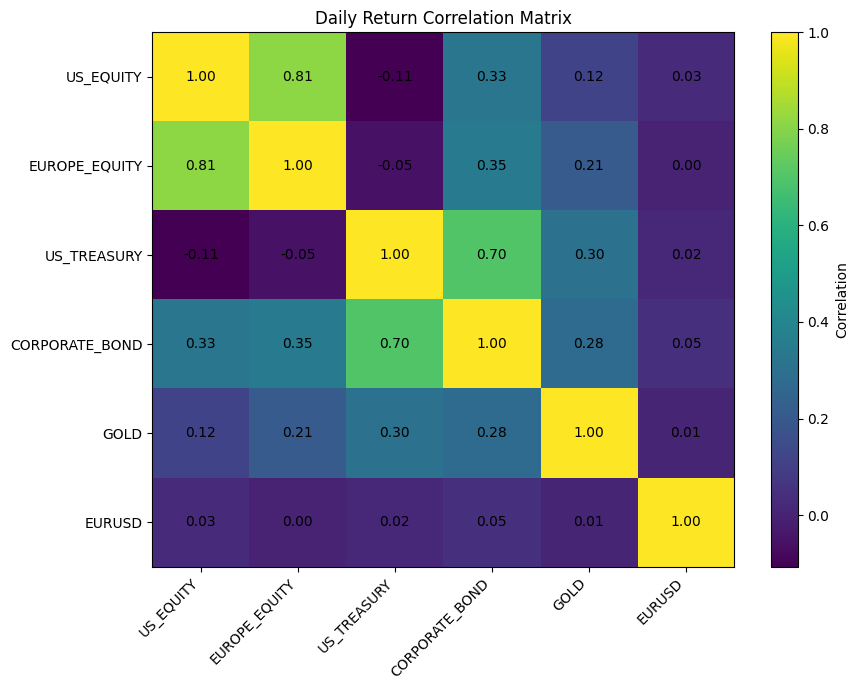

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))

correlation_image = ax.imshow(
    correlation_matrix,
    aspect="auto",
)

ax.set_xticks(
    range(len(correlation_matrix.columns))
)

ax.set_yticks(
    range(len(correlation_matrix.index))
)

ax.set_xticklabels(
    correlation_matrix.columns,
    rotation=45,
    ha="right",
)

ax.set_yticklabels(
    correlation_matrix.index
)

for row_index in range(len(correlation_matrix.index)):
    for column_index in range(
        len(correlation_matrix.columns)
    ):
        ax.text(
            column_index,
            row_index,
            f"{correlation_matrix.iloc[row_index, column_index]:.2f}",
            ha="center",
            va="center",
        )

ax.set_title("Daily Return Correlation Matrix")
fig.colorbar(
    correlation_image,
    ax=ax,
    label="Correlation",
)

plt.tight_layout()
plt.show()

## Volatilité glissante

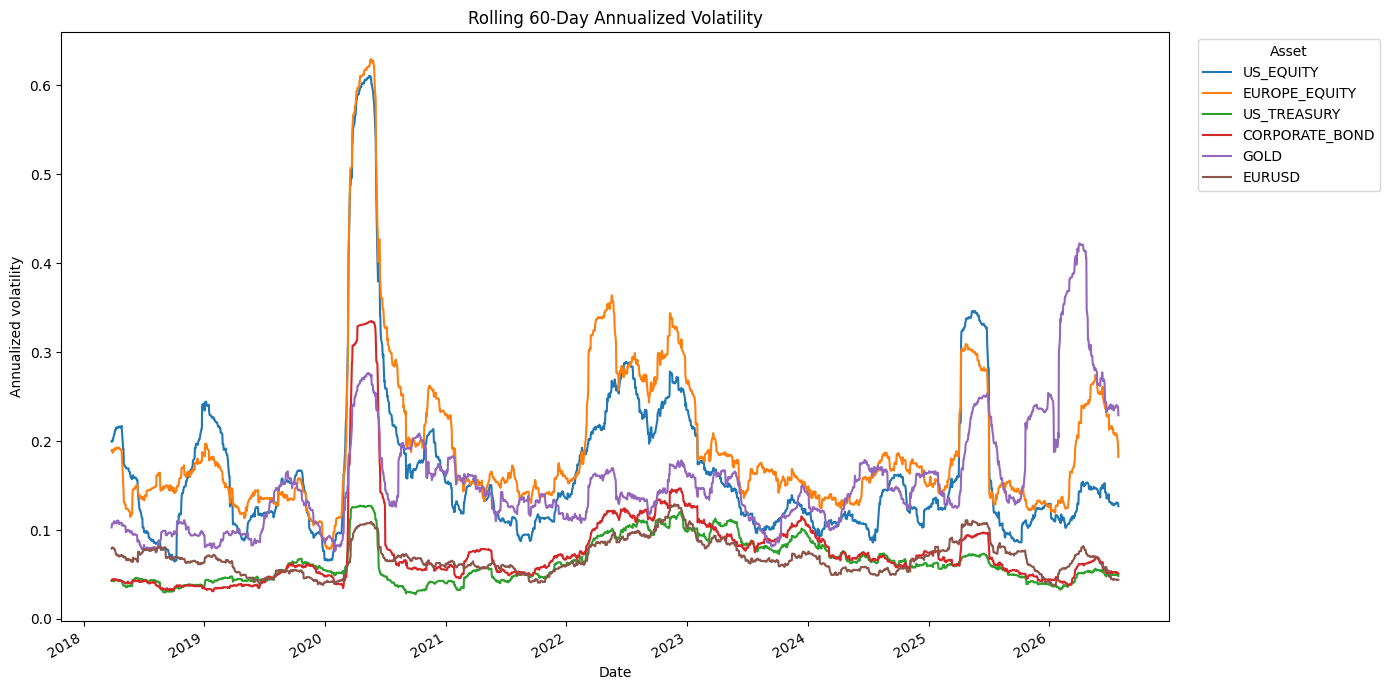

In [ ]:
ROLLING_WINDOW = 60

rolling_volatility = (
    simple_returns
    .rolling(ROLLING_WINDOW)
    .std()
    * np.sqrt(TRADING_DAYS_PER_YEAR)
)

rolling_volatility.plot(
    figsize=(14, 7),
    title=(
        f"Rolling {ROLLING_WINDOW}-Day "
        "Annualized Volatility"
    ),
)

plt.xlabel("Date")
plt.ylabel("Annualized volatility")
plt.legend(
    title="Asset",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)
plt.tight_layout()
plt.show()

## Calcul des drawdowns

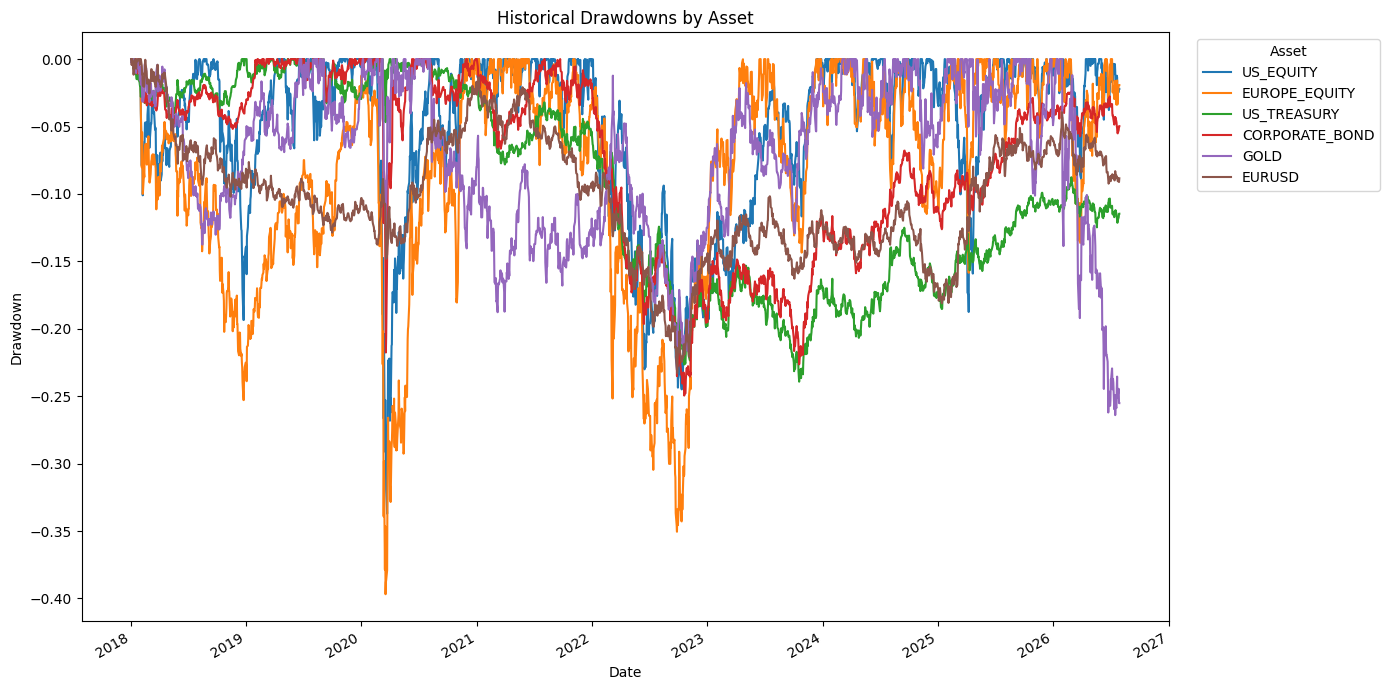

In [ ]:
def calculate_drawdowns(
    prices: pd.DataFrame,
) -> pd.DataFrame:
    """Calculate drawdowns from historical price series."""

    running_maximum = prices.cummax()

    drawdowns = (
        prices / running_maximum
    ) - 1

    return drawdowns


drawdowns = calculate_drawdowns(
    clean_prices
)

drawdowns.plot(
    figsize=(14, 7),
    title="Historical Drawdowns by Asset",
)

plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend(
    title="Asset",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)
plt.tight_layout()
plt.show()

In [ ]:
drawdown_summary = pd.DataFrame({
    "maximum_drawdown": drawdowns.min(),
    "maximum_drawdown_date": [
        drawdowns[column].idxmin()
        for column in drawdowns.columns
    ],
})

drawdown_summary

,maximum_drawdown,maximum_drawdown_date
asset,,
US_EQUITY,-0.337173,2020-03-23
EUROPE_EQUITY,-0.396877,2020-03-18
US_TREASURY,-0.239248,2023-10-19
CORPORATE_BOND,-0.249549,2022-10-20
GOLD,-0.264045,2026-07-16
EURUSD,-0.232919,2022-09-28


## Rapport final de qualité

In [ ]:
final_quality_report = build_data_quality_report(
    clean_prices
)

final_quality_report["raw_missing_count"] = (
    raw_prices.isna().sum()
)

final_quality_report["cleaning_observations_removed"] = (
    len(raw_prices) - len(clean_prices)
)

final_quality_report["return_observation_count"] = (
    len(simple_returns)
)

final_quality_report["extreme_return_count"] = [
    simple_returns[column]
    .abs()
    .ge(EXTREME_RETURN_THRESHOLD)
    .sum()
    for column in simple_returns.columns
]

final_quality_report

,observation_count,missing_count,missing_rate,first_valid_date,last_valid_date,minimum_price,maximum_price,zero_or_negative_count,duplicate_date_count,raw_missing_count,cleaning_observations_removed,return_observation_count,extreme_return_count
asset,,,,,,,,,,,,,
US_EQUITY,2233,0,0.000000,2018-01-02,2026-07-29,204.418213,757.618225,0,0,81,1,2232,0
EUROPE_EQUITY,2233,0,0.000000,2018-01-02,2026-07-29,20.856178,69.529999,0,0,81,1,2232,0
US_TREASURY,2233,0,0.000000,2018-01-02,2026-07-29,80.396271,105.679947,0,0,81,1,2232,0
CORPORATE_BOND,2233,0,0.000000,2018-01-02,2026-07-29,83.536102,112.422020,0,0,81,1,2232,0
GOLD,2233,0,0.000000,2018-01-02,2026-07-29,111.099998,495.899994,0,0,81,1,2232,0
EURUSD,2233,0,0.000000,2018-01-02,2026-07-29,0.959619,1.251001,0,0,2,1,2232,0


## Enregistrer les sorties du notebook 1

In [ ]:
OUTPUT_FILES = {
    "clean_prices_csv":
        DATA_PROCESSED_DIR / "market_prices.csv",

    "clean_prices_parquet":
        DATA_PROCESSED_DIR / "market_prices.parquet",

    "simple_returns_csv":
        DATA_PROCESSED_DIR / "market_returns.csv",

    "simple_returns_parquet":
        DATA_PROCESSED_DIR / "market_returns.parquet",

    "log_returns_csv":
        DATA_PROCESSED_DIR / "market_log_returns.csv",

    "log_returns_parquet":
        DATA_PROCESSED_DIR / "market_log_returns.parquet",

    "asset_reference":
        CONFIG_DIR / "asset_reference.csv",

    "data_quality_report":
        REPORTS_DIR / "data_quality_report.csv",

    "market_statistics":
        REPORTS_DIR / "market_statistics.csv",

    "correlation_matrix":
        REPORTS_DIR / "correlation_matrix.csv",

    "drawdown_summary":
        REPORTS_DIR / "drawdown_summary.csv",

    "extreme_returns":
        REPORTS_DIR / "extreme_returns.csv",
}

clean_prices.to_csv(
    OUTPUT_FILES["clean_prices_csv"],
)

clean_prices.to_parquet(
    OUTPUT_FILES["clean_prices_parquet"],
)

simple_returns.to_csv(
    OUTPUT_FILES["simple_returns_csv"],
)

simple_returns.to_parquet(
    OUTPUT_FILES["simple_returns_parquet"],
)

log_returns.to_csv(
    OUTPUT_FILES["log_returns_csv"],
)

log_returns.to_parquet(
    OUTPUT_FILES["log_returns_parquet"],
)

asset_reference.to_csv(
    OUTPUT_FILES["asset_reference"],
)

final_quality_report.to_csv(
    OUTPUT_FILES["data_quality_report"],
)

market_statistics.to_csv(
    OUTPUT_FILES["market_statistics"],
)

correlation_matrix.to_csv(
    OUTPUT_FILES["correlation_matrix"],
)

drawdown_summary.to_csv(
    OUTPUT_FILES["drawdown_summary"],
)

extreme_returns.to_csv(
    OUTPUT_FILES["extreme_returns"],
    index=False,
)

print("Notebook outputs saved successfully.")

Notebook outputs saved successfully.


## Créer une empreinte des fichiers

In [ ]:
def calculate_file_hash(
    file_path: Path,
) -> str:
    """Calculate a SHA-256 hash for a file."""

    sha256 = hashlib.sha256()

    with open(file_path, "rb") as file:
        for block in iter(
            lambda: file.read(8192),
            b"",
        ):
            sha256.update(block)

    return sha256.hexdigest()

In [ ]:
DEPENDENCY_FILES_FOR_NOTEBOOK_02 = [
    OUTPUT_FILES["clean_prices_parquet"],
    OUTPUT_FILES["simple_returns_parquet"],
    OUTPUT_FILES["asset_reference"],
]

file_hashes = {
    file_path.name: calculate_file_hash(file_path)
    for file_path in DEPENDENCY_FILES_FOR_NOTEBOOK_02
}

file_hashes

{'market_prices.parquet': '819c31cbc8bd05bac8330bec6d82245010625ba55b6d7f10e614b1c9761543f2',
 'market_returns.parquet': 'fa9a0a614d0e8b3c644aa1a8fa4c11f60279a12f8e1a2b5a1625d5578a22b0a6',
 'asset_reference.csv': 'c53b40a8811f4e5c06787811f006bcb5e81aef90f29371b0b902bbff10fcab11'}

## Créer le manifeste de dépendance

C’est la partie centrale de la dépendance entre les notebooks.

In [ ]:
PIPELINE_MANIFEST_PATH = (
    CONFIG_DIR / "pipeline_manifest.json"
)

generation_time = datetime.now(
    timezone.utc
).isoformat()

pipeline_manifest = {
    "pipeline_name": "Market Risk Analytics Platform",
    "pipeline_version": PIPELINE_VERSION,
    "producer_notebook": (
        "01_data_collection_and_market_analysis.ipynb"
    ),
    "generated_at_utc": generation_time,
    "data_source": "Yahoo Finance via yfinance",
    "requested_start_date": START_DATE,
    "requested_end_date": END_DATE,
    "actual_start_date": str(
        clean_prices.index.min().date()
    ),
    "actual_end_date": str(
        clean_prices.index.max().date()
    ),
    "assets": ASSET_NAMES,
    "tickers": TICKERS,
    "price_observations": int(
        len(clean_prices)
    ),
    "return_observations": int(
        len(simple_returns)
    ),
    "price_columns": clean_prices.columns.tolist(),
    "return_columns": simple_returns.columns.tolist(),
    "missing_values_after_cleaning": int(
        clean_prices.isna().sum().sum()
    ),
    "notebook_02_dependencies": [
        str(
            OUTPUT_FILES[
                "clean_prices_parquet"
            ].relative_to(PROJECT_ROOT)
        ),
        str(
            OUTPUT_FILES[
                "simple_returns_parquet"
            ].relative_to(PROJECT_ROOT)
        ),
        str(
            OUTPUT_FILES[
                "asset_reference"
            ].relative_to(PROJECT_ROOT)
        ),
    ],
    "file_hashes": file_hashes,
    "status": "SUCCESS",
}

with open(
    PIPELINE_MANIFEST_PATH,
    "w",
    encoding="utf-8",
) as manifest_file:
    json.dump(
        pipeline_manifest,
        manifest_file,
        indent=4,
        ensure_ascii=False,
    )

print(
    f"Pipeline manifest saved to: "
    f"{PIPELINE_MANIFEST_PATH}"
)

Pipeline manifest saved to: /content/drive/MyDrive/market-risk-analytics/config/pipeline_manifest.json


In [ ]:
pipeline_manifest

{'pipeline_name': 'Market Risk Analytics Platform',
 'pipeline_version': '1.0.0',
 'producer_notebook': '01_data_collection_and_market_analysis.ipynb',
 'generated_at_utc': '2026-07-29T05:53:48.545556+00:00',
 'data_source': 'Yahoo Finance via yfinance',
 'requested_start_date': '2018-01-01',
 'requested_end_date': None,
 'actual_start_date': '2018-01-02',
 'actual_end_date': '2026-07-29',
 'assets': ['US_EQUITY',
  'EUROPE_EQUITY',
  'US_TREASURY',
  'CORPORATE_BOND',
  'GOLD',
  'EURUSD'],
 'tickers': ['SPY', 'FEZ', 'IEF', 'LQD', 'GLD', 'EURUSD=X'],
 'price_observations': 2233,
 'return_observations': 2232,
 'price_columns': ['US_EQUITY',
  'EUROPE_EQUITY',
  'US_TREASURY',
  'CORPORATE_BOND',
  'GOLD',
  'EURUSD'],
 'return_columns': ['US_EQUITY',
  'EUROPE_EQUITY',
  'US_TREASURY',
  'CORPORATE_BOND',
  'GOLD',
  'EURUSD'],
 'missing_values_after_cleaning': 0,
 'notebook_02_dependencies': ['data/processed/market_prices.parquet',
  'data/processed/market_returns.parquet',
  'config/

## Validation finale des dépendances

In [ ]:
def validate_notebook_01_outputs(
    required_files: list[Path],
    manifest_path: Path,
) -> None:
    """Validate all outputs required by Notebook 02."""

    missing_files = [
        file_path
        for file_path in required_files
        if not file_path.exists()
    ]

    if missing_files:
        raise FileNotFoundError(
            "Notebook 01 failed to create the "
            f"following files: {missing_files}"
        )

    empty_files = [
        file_path
        for file_path in required_files
        if file_path.stat().st_size == 0
    ]

    if empty_files:
        raise ValueError(
            f"Empty output files detected: {empty_files}"
        )

    if not manifest_path.exists():
        raise FileNotFoundError(
            "The pipeline manifest was not created."
        )

    with open(
        manifest_path,
        "r",
        encoding="utf-8",
    ) as manifest_file:
        manifest = json.load(manifest_file)

    if manifest.get("status") != "SUCCESS":
        raise ValueError(
            "The pipeline manifest does not report SUCCESS."
        )

    if manifest.get("producer_notebook") != (
        "01_data_collection_and_market_analysis.ipynb"
    ):
        raise ValueError(
            "Unexpected producer notebook in manifest."
        )

    print("All Notebook 01 dependencies are valid.")
    print("Notebook 02 can now be executed.")


validate_notebook_01_outputs(
    required_files=DEPENDENCY_FILES_FOR_NOTEBOOK_02,
    manifest_path=PIPELINE_MANIFEST_PATH,
)

All Notebook 01 dependencies are valid.
Notebook 02 can now be executed.


## Test de rechargement

In [ ]:
reloaded_prices = pd.read_parquet(
    OUTPUT_FILES["clean_prices_parquet"]
)

reloaded_returns = pd.read_parquet(
    OUTPUT_FILES["simple_returns_parquet"]
)

reloaded_asset_reference = pd.read_csv(
    OUTPUT_FILES["asset_reference"],
    index_col=0,
)

assert reloaded_prices.shape == clean_prices.shape
assert reloaded_returns.shape == simple_returns.shape

assert (
    reloaded_prices.columns.tolist()
    == clean_prices.columns.tolist()
)

assert (
    reloaded_returns.columns.tolist()
    == simple_returns.columns.tolist()
)

assert not reloaded_prices.isna().any().any()
assert not reloaded_returns.isna().any().any()

print("Reloading test successful.")
print(f"Prices shape: {reloaded_prices.shape}")
print(f"Returns shape: {reloaded_returns.shape}")

Reloading test successful.
Prices shape: (2233, 6)
Returns shape: (2232, 6)


## Résumé final

In [ ]:
notebook_summary = pd.DataFrame({
    "indicator": [
        "Pipeline status",
        "Pipeline version",
        "Number of assets",
        "Price observations",
        "Return observations",
        "Start date",
        "End date",
        "Missing prices after cleaning",
        "Files required by Notebook 02",
    ],
    "value": [
        "SUCCESS",
        PIPELINE_VERSION,
        len(ASSET_NAMES),
        len(clean_prices),
        len(simple_returns),
        clean_prices.index.min().date(),
        clean_prices.index.max().date(),
        int(clean_prices.isna().sum().sum()),
        len(DEPENDENCY_FILES_FOR_NOTEBOOK_02),
    ],
})

notebook_summary

,indicator,value
0,Pipeline status,SUCCESS
1,Pipeline version,1.0.0
2,Number of assets,6
3,Price observations,2233
4,Return observations,2232
5,Start date,2018-01-02
6,End date,2026-07-29
7,Missing prices after cleaning,0
8,Files required by Notebook 02,3


## Conclusion

Notebook 01 successfully established the market-data layer of the Market Risk Analytics Platform.

### Main outputs

- Historical prices were collected for a diversified multi-asset universe.
- Data-quality checks were performed before and after cleaning.
- Trading calendars were aligned using a limited forward-fill methodology.
- Simple and logarithmic returns were calculated.
- Initial market-risk indicators were analyzed:
  - annualized volatility;
  - return distributions;
  - correlations;
  - rolling volatility;
  - historical drawdowns.
- Processed datasets were exported in CSV and Parquet formats.
- A pipeline manifest was generated to manage dependencies and ensure reproducibility.

### Dependency created for Notebook 02

Notebook 02 must load and validate:

- `data/processed/market_prices.parquet`;
- `data/processed/market_returns.parquet`;
- `config/asset_reference.csv`;
- `config/pipeline_manifest.json`.

### Next step

Notebook 02 will use these datasets to construct the portfolio and calculate:

- asset exposures;
- portfolio returns;
- daily and cumulative P&L;
- portfolio value;
- P&L contributions by position.